# 16 · `hsv_composite`

`Map.hsv_composite` stacks three bands into **an HSV→RGB image** (cleopatra `ArrayGlyph` RGB path). Here three terrain-derived bands (elevation, gradient magnitude, smoothed elevation) form the composite.

**Setup** — inline plots and the path to the bundled Lisbon DEM.

In [1]:
%matplotlib inline
from pathlib import Path

# Locate the bundled Lisbon DEM from the repo root (works from docs/ or the repo root).
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "LisbonElevation.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DEM = str(ROOT / "examples" / "data" / "LisbonElevation.tif")
from pyramids.dataset import Dataset
from digitalearth.scene import Map
ds = Dataset.read_file(DEM)
import numpy as np
z = np.nan_to_num(ds.read_array(band=0).astype('float32'))
dy, dx = np.gradient(z)
grad = np.hypot(dx, dy).astype('float32')
from numpy.lib.stride_tricks import sliding_window_view as swv
k = 5
sm = swv(np.pad(z, k // 2, mode='edge'), (k, k)).mean(axis=(-1, -2)).astype('float32')
rgb = Dataset.create_from_array(arr=np.stack([z, grad, sm]), geo=ds.geotransform, epsg=ds.epsg)

Composite the three bands with `Map.hsv_composite`.

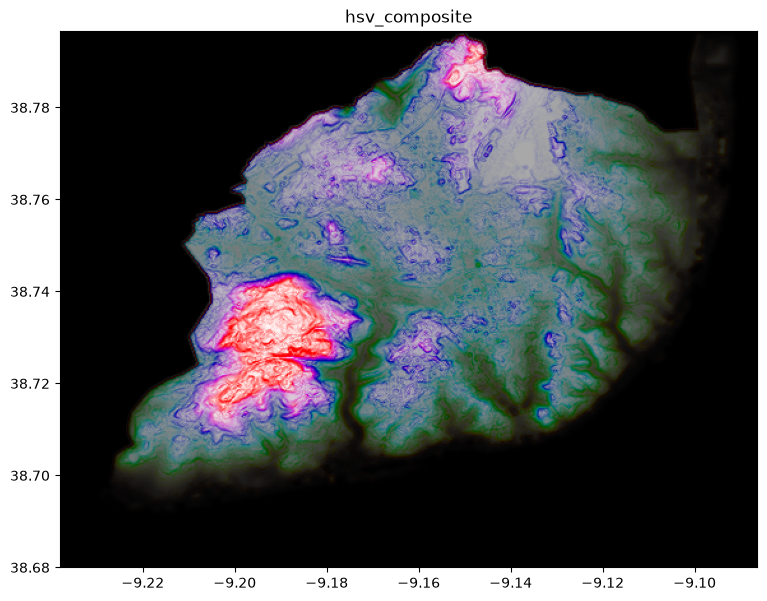

In [2]:
m = Map(crs=rgb.epsg, figsize=(9, 7))
m.hsv_composite(rgb)
m.set_title('hsv_composite')
m.fig;